# Testing

## ConvLSTM

In [12]:
import os
import glob
import re
import cv2
import torch
import numpy as np
import warnings
import multiprocessing
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# --- CONVLSTM CONFIG (SUPER FAST) ---
SEQ_CONFIG = {
    'seq_len': 5,
    'hidden_dim': 256,
    'lstm_layers': 1,
    'batch_size': 32,      # Increased to 32 (Frozen backbone allows this)
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\ConvLSTM',
    'device': CONFIG['device'],
    'num_workers': 0,      # Keep 0 for Windows stability
    'stride': 4            # <--- KEY CHANGE: Skip overlapping frames
}

os.makedirs(SEQ_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ Config Loaded. Batch Size: {SEQ_CONFIG['batch_size']}, Stride: {SEQ_CONFIG['stride']}")

# --- OPTIMIZED DATASET CLASS ---
class SequentialDataset(Dataset):
    def __init__(self, img_dir, seq_len=5, stride=1):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.samples = [] 
        
        # 1. Group images by Video ID
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows (Reduces Redundancy)
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            # stride=seq_len means NO overlap (fastest)
            # stride=seq_len//2 means 50% overlap
            if len(frames) >= seq_len:
                # The step argument in range() is the stride
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_tensor = torch.from_numpy(np.array(images)).float() / 255.0
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

# Generate Data with Stride
seq_dataset = SequentialDataset(CONFIG['save_dir'], seq_len=SEQ_CONFIG['seq_len'], stride=SEQ_CONFIG['stride'])
print(f"✅ Optimized Dataset: {len(seq_dataset)} unique sequences (Reduced redundancy).")

✅ Config Loaded. Batch Size: 32, Stride: 4
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Optimized Dataset: 21136 unique sequences (Reduced redundancy).


In [13]:
import torch.nn as nn
import torchvision.models as models

class ResNetLSTM_Optimized(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=1, freeze_backbone=True):
        super(ResNetLSTM_Optimized, self).__init__()
        
        # Feature Extractor
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-1] 
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        # Freeze Backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen")
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        c_in = x.view(batch_size * seq_len, c, h, w)
        
        features = self.backbone(c_in) 
        features = features.view(batch_size, seq_len, -1) 
        
        lstm_out, _ = self.lstm(features)
        last_out = lstm_out[:, -1, :] 
        
        logits = self.fc(last_out)
        return logits.squeeze(1)

In [14]:
# --- SPLIT & LOADERS ---
seq_labels = [s['label'] for s in seq_dataset.samples]
indices = np.arange(len(seq_dataset))

# Stratified Split
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=seq_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[seq_labels[i] for i in temp_idx], random_state=42)

train_loader_seq = DataLoader(Subset(seq_dataset, train_idx), batch_size=SEQ_CONFIG['batch_size'], shuffle=True, num_workers=SEQ_CONFIG['num_workers'])
val_loader_seq = DataLoader(Subset(seq_dataset, val_idx), batch_size=SEQ_CONFIG['batch_size'], shuffle=False, num_workers=SEQ_CONFIG['num_workers'])

print(f"✅ Fast Loaders Ready. Train Batches: {len(train_loader_seq)} (Should be much lower now)")

✅ Fast Loaders Ready. Train Batches: 463 (Should be much lower now)


In [15]:
# --- CELL 12: LOAD PRE-TRAINED MODEL ---
import torch
import os
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score
from tqdm import tqdm

# 1. Init Model Architecture
# (Must exactly match the configuration used during training)
print("🏗️ Initializing Model Architecture...")
model_lstm = ResNetLSTM_Optimized(
    hidden_dim=SEQ_CONFIG['hidden_dim'], 
    num_layers=SEQ_CONFIG['lstm_layers'],
    freeze_backbone=True 
)
model_lstm.to(SEQ_CONFIG['device'])

# 2. Load Weights
# Assuming the file name is 'best_convlstm.pth' based on your previous code
weights_path = r"H:\DPJI\ConvLSTM\best_convlstm.pth"

if os.path.exists(weights_path):
    print(f"🔄 Loading weights from: {weights_path}")
    state_dict = torch.load(weights_path, map_location=SEQ_CONFIG['device'])
    model_lstm.load_state_dict(state_dict)
    print("✅ Weights loaded successfully.")
else:
    raise FileNotFoundError(f"❌ Could not find model file at: {weights_path}")

# 3. Validate (To verify the model loaded correctly)
print("🚀 Validating Loaded Model...")
model_lstm.eval()
val_preds, val_lbls = [], []

with torch.no_grad():
    for batch in tqdm(val_loader_seq, desc="Validation"):
        imgs = batch['images'].to(SEQ_CONFIG['device'], non_blocking=True)
        # Forward pass
        logits = model_lstm(imgs)
        # Store predictions
        val_preds.extend(torch.sigmoid(logits).cpu().numpy())
        val_lbls.extend(batch['label'].numpy())

# 4. Metrics
f1 = f1_score(val_lbls, (np.array(val_preds) > 0.5).astype(int))
try: 
    auc = roc_auc_score(val_lbls, val_preds)
except: 
    auc = 0.5

print(f"\n📊 Model Performance:")
print(f"   F1 Score: {f1:.4f}")
print(f"   AUC:      {auc:.4f}")

🏗️ Initializing Model Architecture...
❄️ ResNet Backbone Frozen
🔄 Loading weights from: H:\DPJI\ConvLSTM\best_convlstm.pth
✅ Weights loaded successfully.
🚀 Validating Loaded Model...


Validation: 100%|████████████████████████████████████████████████████████████| 100/100 [03:42<00:00,  2.22s/it]


📊 Model Performance:
   F1 Score: 0.7669
   AUC:      0.7560


In [16]:
# --- CELL 12: LOAD FULL CHECKPOINT ---
import torch
import torch.optim as optim
import os

# 1. Define Path
checkpoint_path = r"H:\DPJI\ConvLSTM\full_checkpoint_lstm.pth"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ Checkpoint not found at: {checkpoint_path}")

print(f"🔄 Loading Checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=SEQ_CONFIG['device'])

# 2. Init Model Architecture
# (Must exactly match the structure used when saving)
model_lstm = ResNetLSTM_Optimized(
    hidden_dim=SEQ_CONFIG['hidden_dim'], 
    num_layers=SEQ_CONFIG['lstm_layers'],
    freeze_backbone=True 
)
model_lstm.to(SEQ_CONFIG['device'])

# 3. Init Optimizer
# (Required if you want to resume training, otherwise optional but good for completeness)
params = [p for p in model_lstm.parameters() if p.requires_grad]
optimizer = optim.Adam(params, lr=SEQ_CONFIG['lr'])

# 4. Load State Dictionaries
try:
    # Load Model Weights
    model_lstm.load_state_dict(checkpoint['model_state_dict'])
    print("   ✅ Model weights loaded.")

    # Load Optimizer State
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("   ✅ Optimizer state loaded.")
    
except RuntimeError as e:
    print(f"   ⚠️ Error loading state dict (Shape mismatch?): {e}")

# 5. Retrieve Metadata
saved_metrics = checkpoint.get('metrics', {})
saved_config = checkpoint.get('config', {})

print("-" * 30)
print("📊 Checkpoint Info:")
print(f"   Saved F1 Score: {saved_metrics.get('f1', 'N/A')}")
print(f"   Architecture:   {saved_config.get('lstm_layers', 'N/A')} LSTM Layers")
print("✅ Ready for Inference or Resuming Training.")

🔄 Loading Checkpoint from: H:\DPJI\ConvLSTM\full_checkpoint_lstm.pth
❄️ ResNet Backbone Frozen
   ✅ Model weights loaded.
   ✅ Optimizer state loaded.
------------------------------
📊 Checkpoint Info:
   Saved F1 Score: 0.7669461077844312
   Architecture:   1 LSTM Layers
✅ Ready for Inference or Resuming Training.


In [17]:
# --- CELL 6: CREATE TEST LOADER ---
# Use the test_idx generated in Cell 3
print(f"📂 Creating Test Loader for {len(test_idx)} samples...")

test_loader_seq = DataLoader(
    Subset(seq_dataset, test_idx), 
    batch_size=SEQ_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=SEQ_CONFIG['num_workers']
)

print(f"✅ Test Loader Ready. Batches: {len(test_loader_seq)}")

📂 Creating Test Loader for 3171 samples...
✅ Test Loader Ready. Batches: 100


In [18]:
# --- CELL 7: RUN TESTING ON SEQ TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_seq_testing(model, loader, device):
    print(f"🚀 Starting ConvLSTM Inference on Test Set ({len(loader.dataset)} sequences)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Input Shape: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True)
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            all_probs.extend(probs)
            all_targets.extend(targets)

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 CONVLSTM FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_seq_testing(model_lstm, test_loader_seq, SEQ_CONFIG['device'])

🚀 Starting ConvLSTM Inference on Test Set (3171 sequences)...


Testing: 100%|███████████████████████████████████████████████████████████████| 100/100 [03:27<00:00,  2.08s/it]


🏆 CONVLSTM FINAL TEST RESULTS (N=3171)
✅ Accuracy:      0.7020
✅ Precision:     0.7298
✅ Recall:        0.8212
✅ F1 Score:      0.7728
✅ ROC AUC:       0.7667
❌ Test Loss:     0.6695
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.64      0.51      0.57      1214
    Crossing       0.73      0.82      0.77      1957

    accuracy                           0.70      3171
   macro avg       0.68      0.67      0.67      3171
weighted avg       0.69      0.70      0.69      3171



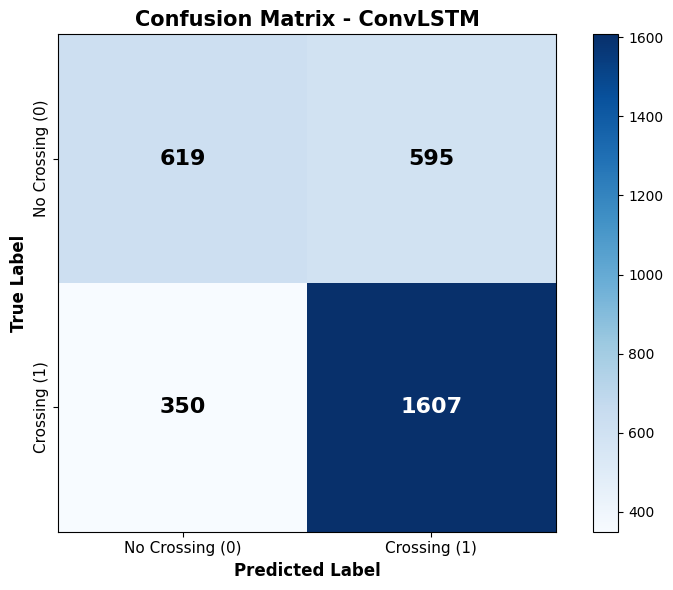

In [22]:
# --- CELL 8: VISUALIZE CONFUSION MATRIX (High Contrast Fix) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. Setup Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix - ConvLSTM', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 3. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 4. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    # Threshold: determine when to switch text color from black to white
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 # Logic: If value is high (dark background), use White text. Else Black.
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the robust plotter
plot_confusion_matrix_robust(y_true, y_pred)

## C3D

In [25]:
# --- C3D / R3D CONFIG ---
C3D_CONFIG = {
    'seq_len': 16,         # 3D CNNs prefer longer clips (16 frames is standard for R3D)
    'hidden_dim': 512,
    'batch_size': 8,       # 3D Convs are heavy on VRAM, so we lower batch size slightly
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\C3D',
    'device': CONFIG['device'],
    'num_workers': 0,      # Windows stability
    'stride': 4            # Skip overlapping frames to reduce data size
}

os.makedirs(C3D_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ C3D Config Loaded. Sequence Length: {C3D_CONFIG['seq_len']}")

✅ C3D Config Loaded. Sequence Length: 16


In [26]:
# --- DATASET FOR 3D CNN ---
# We reuse the SequentialDataset class, just initializing with new seq_len
print(f"🔄 Generating {C3D_CONFIG['seq_len']}-frame sequences...")

c3d_dataset = SequentialDataset(
    CONFIG['save_dir'], 
    seq_len=C3D_CONFIG['seq_len'], 
    stride=C3D_CONFIG['stride']
)

print(f"✅ C3D Dataset Ready: {len(c3d_dataset)} clips.")

🔄 Generating 16-frame sequences...
Grouping files into sequences...


✅ C3D Dataset Ready: 21046 clips.


In [27]:
import torchvision.models.video as video_models

class PedestrianR3D(nn.Module):
    def __init__(self, freeze_backbone=True):
        super(PedestrianR3D, self).__init__()
        
        # 1. Load Pre-trained 3D ResNet
        # (Weights trained on Kinetics-400 action dataset)
        self.backbone = video_models.r3d_18(weights='KINETICS400_V1')
        
        # 2. Modify the Final Classification Layer
        # R3D-18 default fc is Linear(512, 400). We change to Linear(512, 1)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)
        
        # 3. Freeze Backbone (Optimization)
        if freeze_backbone:
            print("❄️ Freezing 3D Backbone layers...")
            # Freeze everything except the new FC layer and the last block
            for name, param in self.backbone.named_parameters():
                if 'fc' not in name and 'layer4' not in name:
                    param.requires_grad = False
            print("✅ Backbone Frozen. Training only Layer 4 + Classifier.")

    def forward(self, x):
        # x shape: [Batch, Channel, Time, Height, Width]
        return self.backbone(x).squeeze(1)

print("✅ PedestrianR3D Model Defined.")

✅ PedestrianR3D Model Defined.


In [28]:
# --- SPLIT & LOADERS ---
c3d_labels = [s['label'] for s in c3d_dataset.samples]
indices = np.arange(len(c3d_dataset))

# Stratified Split
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=c3d_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[c3d_labels[i] for i in temp_idx], random_state=42)

# Loaders
train_loader_c3d = DataLoader(
    Subset(c3d_dataset, train_idx), 
    batch_size=C3D_CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=C3D_CONFIG['num_workers']
)

val_loader_c3d = DataLoader(
    Subset(c3d_dataset, val_idx), 
    batch_size=C3D_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=C3D_CONFIG['num_workers']
)

print(f"✅ C3D Loaders Ready. Train Batches: {len(train_loader_c3d)}")

✅ C3D Loaders Ready. Train Batches: 1842


In [29]:
# --- LOAD PRE-TRAINED C3D MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score
from tqdm.notebook import tqdm
import numpy as np

# 1. Define Path
load_path_c3d = os.path.join(C3D_CONFIG['model_save_dir'], "best_c3d.pth")

# 2. Initialize Architecture (Must match training exactly)
# We set freeze_backbone=True because that's how it was trained
model_c3d = PedestrianR3D(freeze_backbone=True)
model_c3d.to(C3D_CONFIG['device'])

# 3. Load Weights
if os.path.exists(load_path_c3d):
    print(f"🔄 Loading pre-trained C3D weights from: {load_path_c3d}")
    
    # Load state dict
    state_dict = torch.load(load_path_c3d, map_location=C3D_CONFIG['device'])
    model_c3d.load_state_dict(state_dict)
    model_c3d.eval()
    
    print("✅ Model weights loaded successfully.")

    # 4. (Optional) Quick Verification on Validation Set
    # This confirms the loaded model works as expected
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion (needed for consistent loss calc)
    train_y = [c3d_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(C3D_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    val_loss = 0
    all_preds, all_lbls = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader_c3d, desc="Validating", leave=False):
            # Load & Permute [B, T, C, H, W] -> [B, C, T, H, W]
            imgs = batch['images'].to(C3D_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(C3D_CONFIG['device'], non_blocking=True)
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            logits = model_c3d(imgs)
            loss = criterion(logits, lbls)
            
            val_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
    
    # Metrics
    f1 = f1_score(all_lbls, (np.array(all_preds)>0.5).astype(int))
    try: auc = roc_auc_score(all_lbls, all_preds)
    except: auc = 0.5
    
    print("-" * 40)
    print(f"🏆 Loaded C3D Model Results:")
    print(f"   Val Loss: {val_loss/len(val_loader_c3d):.4f}")
    print(f"   F1 Score: {f1:.4f}")
    print(f"   AUC:      {auc:.4f}")
    print("-" * 40)
    
    # Re-init optimizer (needed if you plan to save full checkpoints later)
    params_to_update = [p for p in model_c3d.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=C3D_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path_c3d}'")
    print("⚠️ Please run the Training Cell first to generate this file.")

❄️ Freezing 3D Backbone layers...
✅ Backbone Frozen. Training only Layer 4 + Classifier.
🔄 Loading pre-trained C3D weights from: H:\DPJI\C3D\best_c3d.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...


Validating:   0%|          | 0/395 [00:00<?, ?it/s]

----------------------------------------
🏆 Loaded C3D Model Results:
   Val Loss: 0.9477
   F1 Score: 0.7776
   AUC:      0.7624
----------------------------------------


In [30]:
# --- LOAD FULL C3D CHECKPOINT ---
import os
import torch
import torch.optim as optim

# 1. Define Path
CHECKPOINT_PATH_C3D = os.path.join(C3D_CONFIG['model_save_dir'], "full_checkpoint_c3d.pth")

if os.path.exists(CHECKPOINT_PATH_C3D):
    print(f"🔄 Found checkpoint at: {CHECKPOINT_PATH_C3D}")
    print("   Loading state dictionaries...")
    
    # 2. Re-Initialize Model & Optimizer
    # We must initialize them first to have the correct structure to load into
    model_c3d = PedestrianR3D(freeze_backbone=True)
    model_c3d.to(C3D_CONFIG['device'])
    
    # Optimizer must be initialized with the parameters that require gradients
    params_to_update = [p for p in model_c3d.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=C3D_CONFIG['lr'])
    
    # 3. Load the File
    # map_location ensures we don't run out of memory if moving between GPU/CPU
    checkpoint = torch.load(CHECKPOINT_PATH_C3D, map_location=C3D_CONFIG['device'])
    
    # 4. Apply States
    try:
        model_c3d.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Model and Optimizer states restored successfully.")
    except RuntimeError as e:
        print(f"⚠️ Error loading states (Shape mismatch?): {e}")

    # 5. Display Stored Metrics
    if 'metrics' in checkpoint:
        best_f1 = checkpoint['metrics'].get('best_f1', 'N/A')
        print("-" * 30)
        print(f"📊 Previous Best F1 Score: {best_f1}")
        print("-" * 30)
        
    # Set to eval mode by default after loading
    model_c3d.eval()

else:
    print(f"❌ Error: Checkpoint file not found at {CHECKPOINT_PATH_C3D}")
    print("   Make sure you have run the 'Save' cell previously.")

🔄 Found checkpoint at: H:\DPJI\C3D\full_checkpoint_c3d.pth
   Loading state dictionaries...
❄️ Freezing 3D Backbone layers...
✅ Backbone Frozen. Training only Layer 4 + Classifier.
✅ Model and Optimizer states restored successfully.
------------------------------
📊 Previous Best F1 Score: 0.7776223776223776
------------------------------


In [31]:
# --- CELL 7: CREATE C3D TEST LOADER ---
# Use the test_idx generated in Cell 4
print(f"📂 Creating Test Loader for {len(test_idx)} clips...")

test_loader_c3d = DataLoader(
    Subset(c3d_dataset, test_idx), 
    batch_size=C3D_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=C3D_CONFIG['num_workers']
)

print(f"✅ C3D Test Loader Ready. Batches: {len(test_loader_c3d)}")

📂 Creating Test Loader for 3157 clips...
✅ C3D Test Loader Ready. Batches: 395


In [32]:
# --- CELL 8: RUN TESTING ON C3D TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_c3d_testing(model, loader, device):
    print(f"🚀 Starting C3D Inference on Test Set ({len(loader.dataset)} clips)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True)
            
            # CRITICAL: Permute to [Batch, C, Seq, H, W] for 3D ResNet
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            all_probs.extend(probs)
            all_targets.extend(targets)

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 C3D FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_c3d_testing(model_c3d, test_loader_c3d, C3D_CONFIG['device'])

🚀 Starting C3D Inference on Test Set (3157 clips)...


Testing:   0%|          | 0/395 [00:00<?, ?it/s]


🏆 C3D FINAL TEST RESULTS (N=3157)
✅ Accuracy:      0.7038
✅ Precision:     0.7134
✅ Recall:        0.8715
✅ F1 Score:      0.7846
✅ ROC AUC:       0.7491
❌ Test Loss:     1.1085
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.67      0.43      0.53      1203
    Crossing       0.71      0.87      0.78      1954

    accuracy                           0.70      3157
   macro avg       0.69      0.65      0.66      3157
weighted avg       0.70      0.70      0.69      3157



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    519
Top-Right (False Alarm):         684
Bot-Left  (Missed Crossing):     251
Bot-Right (Crossing correct):    1703


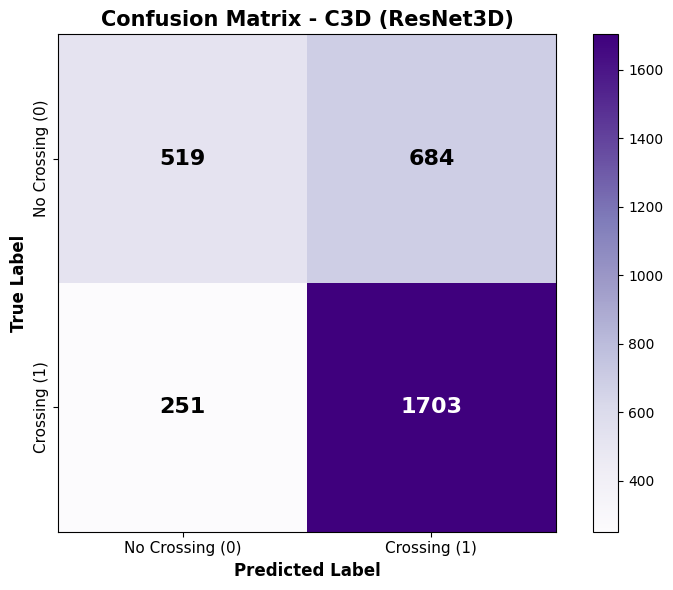

In [33]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'Purples' for C3D to distinguish from others
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Purples) 
    plt.title('Confusion Matrix - C3D (ResNet3D)', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## I3D

In [34]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import autocast, GradScaler
import torchvision.models.video as video_models
from tqdm.notebook import tqdm

# --- I3D / R(2+1)D CONFIG (WINDOWS STABLE & FAST) ---
I3D_CONFIG = {
    'seq_len': 16,          
    'batch_size': 16,       # Keep 16 (Enabled by 112x112 resolution)
    'img_size': (112, 112), # Keep 112x112 (This is the main speedup factor)
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\I3D',
    'device': CONFIG['device'],
    'num_workers': 0,       # <--- FIXED: Must be 0 on Windows Notebooks to prevent freeze
    'stride': 8             # Keep Stride 8 to reduce redundant data
}

os.makedirs(I3D_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ I3D Config Loaded. \n   Resolution: {I3D_CONFIG['img_size']} \n   Batch Size: {I3D_CONFIG['batch_size']} \n   Workers: {I3D_CONFIG['num_workers']}")

✅ I3D Config Loaded. 
   Resolution: (112, 112) 
   Batch Size: 16 
   Workers: 0


In [35]:
# --- OPTIMIZED DATASET CLASS ---
import glob
import re
import cv2
from torch.utils.data import Dataset

class OptimizedI3DDataset(Dataset):
    def __init__(self, img_dir, seq_len=16, stride=8, target_size=(112, 112)):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.target_size = target_size
        self.samples = [] 
        
        # 1. Group images by Video ID
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        files.sort()
        
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            if len(frames) >= seq_len:
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: 
                img = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.uint8)
            else:
                # Resize here (112x112) is the key speedup
                img = cv2.resize(img, self.target_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) # [Seq, C, H, W]
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

print(f"🔄 Generating Optimized I3D Dataset...")
i3d_dataset = OptimizedI3DDataset(
    CONFIG['save_dir'], 
    seq_len=I3D_CONFIG['seq_len'], 
    stride=I3D_CONFIG['stride'],
    target_size=I3D_CONFIG['img_size']
)

# --- SPLITS ---
i3d_labels = [s['label'] for s in i3d_dataset.samples]
indices = np.arange(len(i3d_dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=i3d_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[i3d_labels[i] for i in temp_idx], random_state=42)

# --- LOADERS (Windows Compatible) ---
# persistent_workers removed (requires workers > 0)
train_loader_i3d = DataLoader(
    Subset(i3d_dataset, train_idx), 
    batch_size=I3D_CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader_i3d = DataLoader(
    Subset(i3d_dataset, val_idx), 
    batch_size=I3D_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

print(f"✅ I3D Loaders Ready.\n   Train Samples: {len(train_idx)} ({len(train_loader_i3d)} batches)\n   Val Samples: {len(val_idx)}")

🔄 Generating Optimized I3D Dataset...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ I3D Loaders Ready.
   Train Samples: 7371 (461 batches)
   Val Samples: 1579


In [36]:
# --- MODEL DEFINITION: R(2+1)D ---
class PedestrianI3D(nn.Module):
    def __init__(self, pretrained=True):
        super(PedestrianI3D, self).__init__()
        
        weights = 'KINETICS400_V1' if pretrained else None
        self.backbone = video_models.r2plus1d_18(weights=weights)
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)
        
        # Unfreeze Strategy
        for name, param in self.backbone.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
                
    def forward(self, x):
        return self.backbone(x)

model_i3d = PedestrianI3D(pretrained=True)
model_i3d.to(I3D_CONFIG['device'])
print("✅ I3D (R(2+1)D) Model Initialized.")

✅ I3D (R(2+1)D) Model Initialized.


In [37]:
# --- HELPER FUNCTIONS ---
def train_one_epoch_i3d(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    
    # mininterval prevents the progress bar from updating too fast and lagging IO
    pbar = tqdm(loader, desc="Training", leave=False, mininterval=1.0)
    
    for batch in pbar:
        # Get data
        imgs = batch['images'].to(I3D_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(I3D_CONFIG['device'], non_blocking=True).unsqueeze(1)
        
        # Permute for 3D Conv: [B, C, T, H, W]
        imgs = imgs.permute(0, 2, 1, 3, 4)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

def validate_i3d(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_list, lbls_list = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(I3D_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(I3D_CONFIG['device'], non_blocking=True).unsqueeze(1)
            
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            running_loss += loss.item()
            preds_list.extend(torch.sigmoid(logits).view(-1).cpu().numpy())
            lbls_list.extend(lbls.view(-1).cpu().numpy())
            
    preds_bin = (np.array(preds_list) > 0.5).astype(int)
    acc = accuracy_score(lbls_list, preds_bin)
    f1 = f1_score(lbls_list, preds_bin, zero_division=0)
    try: auc = roc_auc_score(lbls_list, preds_list)
    except: auc = 0.5
    
    return running_loss/len(loader), acc, f1, auc

In [38]:
# --- CELL 5: LOAD PRE-TRAINED I3D MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
import numpy as np

# 1. Define Path
load_path = os.path.join(I3D_CONFIG['model_save_dir'], "best_i3d.pth")

# 2. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained I3D weights from: {load_path}")
    
    # Load state dict
    state_dict = torch.load(load_path, map_location=I3D_CONFIG['device'])
    model_i3d.load_state_dict(state_dict)
    model_i3d.eval()
    
    print("✅ Model weights loaded successfully.")

    # 3. Verify Performance on Validation Set
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion (needed for consistent loss calc in validation function)
    train_y = [i3d_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(I3D_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Run Validation
    v_loss, v_acc, v_f1, v_auc = validate_i3d(model_i3d, val_loader_i3d, criterion)
    
    print("-" * 40)
    print(f"🏆 Loaded I3D Model Results:")
    print(f"   Val Loss: {v_loss:.4f}")
    print(f"   Accuracy: {v_acc:.4f}")
    print(f"   F1 Score: {v_f1:.4f}")
    print(f"   AUC:      {v_auc:.4f}")
    print("-" * 40)
    
    # 4. Re-init optimizer 
    # (Required so that 'optimizer' variable exists if you run Cell 6 to load full checkpoint)
    params_to_update = [p for p in model_i3d.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=I3D_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path}'")
    print("⚠️ Please ensure the model file exists in H:\\DPJI\\I3D")

🔄 Loading pre-trained I3D weights from: H:\DPJI\I3D\best_i3d.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...
----------------------------------------
🏆 Loaded I3D Model Results:
   Val Loss: 0.9297
   Accuracy: 0.7144
   F1 Score: 0.7716
   AUC:      0.7609
----------------------------------------


In [39]:
# --- LOAD CHECKPOINT ---
import os
import torch

LOAD_PATH = os.path.join(I3D_CONFIG['model_save_dir'], "full_checkpoint_i3d.pth")

if os.path.exists(LOAD_PATH):
    print(f"🔄 Loading Checkpoint: {LOAD_PATH}")
    checkpoint = torch.load(LOAD_PATH, map_location=I3D_CONFIG['device'])
    
    # 1. Load Model
    model_i3d.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Load Optimizer
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Optimizer state restored.")
    except Exception as e:
        print(f"⚠️ Could not load optimizer state (Config mismatch?): {e}")
        
    # 3. Metrics
    m = checkpoint.get('metrics', {})
    print("-" * 30)
    print(f"📊 Restored Metrics:")
    print(f"   • Best F1: {m.get('best_f1', 'N/A')}")
    print(f"   • Final AUC: {m.get('final_auc', 'N/A')}")
    print("-" * 30)
    
    model_i3d.eval()

else:
    print(f"❌ Checkpoint not found at {LOAD_PATH}")

🔄 Loading Checkpoint: H:\DPJI\I3D\full_checkpoint_i3d.pth
✅ Optimizer state restored.
------------------------------
📊 Restored Metrics:
   • Best F1: 0.7716455696202532
   • Final AUC: 0.7609052766922128
------------------------------


In [40]:
# --- CELL 7: CREATE I3D TEST LOADER ---
# Use the test_idx generated in Cell 2
print(f"📂 Creating Test Loader for {len(test_idx)} clips...")

test_loader_i3d = DataLoader(
    Subset(i3d_dataset, test_idx), 
    batch_size=I3D_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0, # Keep 0 for Windows stability
    pin_memory=True
)

print(f"✅ I3D Test Loader Ready. Batches: {len(test_loader_i3d)}")

📂 Creating Test Loader for 1580 clips...
✅ I3D Test Loader Ready. Batches: 99


In [41]:
# --- CELL 8: RUN TESTING ON I3D TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_i3d_testing(model, loader, device):
    print(f"🚀 Starting I3D Inference on Test Set ({len(loader.dataset)} clips)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True).unsqueeze(1)
            
            # CRITICAL: Permute to [Batch, C, Seq, H, W] for 3D ResNet
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 I3D FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_i3d_testing(model_i3d, test_loader_i3d, I3D_CONFIG['device'])

🚀 Starting I3D Inference on Test Set (1580 clips)...


Testing:   0%|          | 0/99 [00:00<?, ?it/s]


🏆 I3D FINAL TEST RESULTS (N=1580)
✅ Accuracy:      0.6810
✅ Precision:     0.7460
✅ Recall:        0.7276
✅ F1 Score:      0.7367
✅ ROC AUC:       0.7323
❌ Test Loss:     1.2277
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.58      0.61      0.60       611
    Crossing       0.75      0.73      0.74       969

    accuracy                           0.68      1580
   macro avg       0.67      0.67      0.67      1580
weighted avg       0.68      0.68      0.68      1580



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    371
Top-Right (False Alarm):         240
Bot-Left  (Missed Crossing):     264
Bot-Right (Crossing correct):    705


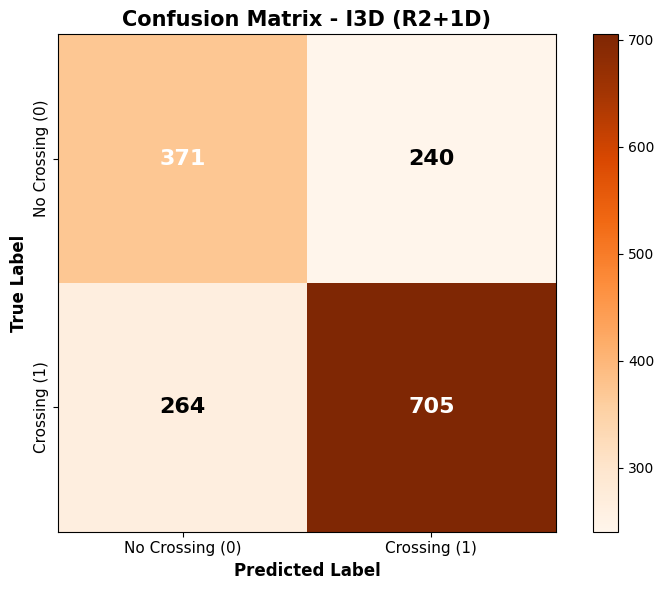

In [42]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'Oranges' for I3D to distinguish from others
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges) 
    plt.title('Confusion Matrix - I3D (R2+1D)', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## SingleRNN

In [43]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
from tqdm.notebook import tqdm
import glob
import re
import cv2

# --- SINGLERNN CONFIG (SPEED OPTIMIZED) ---
RNN_CONFIG = {
    'seq_len': 16,          
    'batch_size': 32,       # Can use higher batch size than I3D (RNN is lighter)
    'img_size': (112, 112), # 112x112 for speed
    'epochs': 10,
    'lr': 1e-4,
    'hidden_dim': 256,
    'lstm_layers': 1,
    'model_save_dir': r'H:\DPJI\SingleRNN',
    'device': CONFIG['device'],
    'num_workers': 0,       # Windows fix
    'stride': 8             # Fast epoch
}

os.makedirs(RNN_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ SingleRNN Config Loaded.\n   Resolution: {RNN_CONFIG['img_size']}\n   Batch Size: {RNN_CONFIG['batch_size']}")

✅ SingleRNN Config Loaded.
   Resolution: (112, 112)
   Batch Size: 32


In [44]:
# --- OPTIMIZED DATASET CLASS FOR RNN ---
class OptimizedRNNDataset(Dataset):
    def __init__(self, img_dir, seq_len=16, stride=8, target_size=(112, 112)):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.target_size = target_size
        self.samples = [] 
        
        # 1. Group images
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        files.sort()
        
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            if len(frames) >= seq_len:
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: 
                img = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.uint8)
            else:
                # Fast Resize
                img = cv2.resize(img, self.target_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        
        # RNN Shape Expectation: [Time, Channel, Height, Width]
        # (Unlike I3D which wanted Channel first)
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

print(f"🔄 Generating Optimized RNN Dataset...")
rnn_dataset = OptimizedRNNDataset(
    CONFIG['save_dir'], 
    seq_len=RNN_CONFIG['seq_len'], 
    stride=RNN_CONFIG['stride'],
    target_size=RNN_CONFIG['img_size']
)

# --- SPLITS ---
rnn_labels = [s['label'] for s in rnn_dataset.samples]
indices = np.arange(len(rnn_dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=rnn_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[rnn_labels[i] for i in temp_idx], random_state=42)

# --- LOADERS ---
train_loader_rnn = DataLoader(Subset(rnn_dataset, train_idx), batch_size=RNN_CONFIG['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
val_loader_rnn = DataLoader(Subset(rnn_dataset, val_idx), batch_size=RNN_CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ RNN Loaders Ready.\n   Train Samples: {len(train_idx)}\n   Val Samples: {len(val_idx)}")

🔄 Generating Optimized RNN Dataset...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ RNN Loaders Ready.
   Train Samples: 7371
   Val Samples: 1579


In [45]:
# --- MODEL DEFINITION: ResNet + LSTM ---
class ResNetSingleRNN(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=1, freeze_backbone=True):
        super(ResNetSingleRNN, self).__init__()
        
        # 1. Feature Extractor (ResNet50)
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-1] # Remove FC layer
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        # Freeze Backbone for speed
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen.")
        
        # 2. LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # 3. Classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Seq, C, H, W]
        b, seq, c, h, w = x.size()
        
        # Flatten time into batch for CNN: [Batch*Seq, C, H, W]
        c_in = x.view(b * seq, c, h, w)
        
        # Extract Features
        features = self.backbone(c_in) # [B*S, 2048, 1, 1]
        features = features.view(b, seq, -1) # [Batch, Seq, 2048]
        
        # LSTM Pass
        lstm_out, _ = self.lstm(features)
        
        # Take last time step
        last_out = lstm_out[:, -1, :] 
        
        # Classify
        return self.fc(last_out)

model_rnn = ResNetSingleRNN(
    hidden_dim=RNN_CONFIG['hidden_dim'],
    num_layers=RNN_CONFIG['lstm_layers']
)
model_rnn.to(RNN_CONFIG['device'])
print("✅ SingleRNN Model Initialized.")

❄️ ResNet Backbone Frozen.
✅ SingleRNN Model Initialized.


In [46]:
# --- HELPER FUNCTIONS ---
def train_one_epoch_rnn(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False, mininterval=1.0)
    for batch in pbar:
        # [B, T, C, H, W]
        imgs = batch['images'].to(RNN_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(RNN_CONFIG['device'], non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

def validate_rnn(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_list, lbls_list = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(RNN_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(RNN_CONFIG['device'], non_blocking=True).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            running_loss += loss.item()
            preds_list.extend(torch.sigmoid(logits).view(-1).cpu().numpy())
            lbls_list.extend(lbls.view(-1).cpu().numpy())
            
    preds_bin = (np.array(preds_list) > 0.5).astype(int)
    acc = accuracy_score(lbls_list, preds_bin)
    f1 = f1_score(lbls_list, preds_bin, zero_division=0)
    try: auc = roc_auc_score(lbls_list, preds_list)
    except: auc = 0.5
    
    return running_loss/len(loader), acc, f1, auc

In [47]:
# --- CELL 5: LOAD PRE-TRAINED SINGLERNN MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
import numpy as np

# 1. Define Path
load_path = os.path.join(RNN_CONFIG['model_save_dir'], "best_rnn.pth")

# 2. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained SingleRNN weights from: {load_path}")
    
    # Load state dict
    state_dict = torch.load(load_path, map_location=RNN_CONFIG['device'])
    model_rnn.load_state_dict(state_dict)
    model_rnn.eval()
    
    print("✅ Model weights loaded successfully.")

    # 3. Verify Performance on Validation Set
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion
    train_y = [rnn_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(RNN_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Run Validation
    v_loss, v_acc, v_f1, v_auc = validate_rnn(model_rnn, val_loader_rnn, criterion)
    
    print("-" * 40)
    print(f"🏆 Loaded SingleRNN Model Results:")
    print(f"   Val Loss: {v_loss:.4f}")
    print(f"   Accuracy: {v_acc:.4f}")
    print(f"   F1 Score: {v_f1:.4f}")
    print(f"   AUC:      {v_auc:.4f}")
    print("-" * 40)
    
    # 4. Re-init optimizer (needed for Cell 6 compatibility)
    params_to_update = [p for p in model_rnn.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=RNN_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path}'")
    print("⚠️ Please ensure the model file exists in H:\\DPJI\\SingleRNN")

🔄 Loading pre-trained SingleRNN weights from: H:\DPJI\SingleRNN\best_rnn.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...
----------------------------------------
🏆 Loaded SingleRNN Model Results:
   Val Loss: 0.4511
   Accuracy: 0.6935
   F1 Score: 0.7290
   AUC:      0.7559
----------------------------------------


In [48]:
# --- LOAD CHECKPOINT ---
import os
import torch

LOAD_PATH = os.path.join(RNN_CONFIG['model_save_dir'], "full_checkpoint_rnn.pth")

if os.path.exists(LOAD_PATH):
    print(f"🔄 Loading Checkpoint: {LOAD_PATH}")
    checkpoint = torch.load(LOAD_PATH, map_location=RNN_CONFIG['device'])
    
    # 1. Load Model
    model_rnn.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Load Optimizer
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Optimizer state restored.")
    except Exception as e:
        print(f"⚠️ Could not load optimizer state: {e}")
        
    # 3. Metrics
    m = checkpoint.get('metrics', {})
    print("-" * 30)
    print(f"📊 Restored Metrics:")
    print(f"   • Best F1: {m.get('best_f1', 'N/A')}")
    print(f"   • Final AUC: {m.get('final_auc', 'N/A')}")
    print("-" * 30)
    
    model_rnn.eval()

else:
    print(f"❌ Checkpoint not found at {LOAD_PATH}")

🔄 Loading Checkpoint: H:\DPJI\SingleRNN\full_checkpoint_rnn.pth
✅ Optimizer state restored.
------------------------------
📊 Restored Metrics:
   • Best F1: 0.729003359462486
   • Final AUC: 0.7003112893129643
------------------------------


In [49]:
# --- CELL 7: CREATE RNN TEST LOADER ---
# We need to recreate the test_idx based on the same random state as Cell 2
print("🔄 Calculating Test Splits...")

# 1. Re-run split logic to find test_idx
indices = np.arange(len(rnn_dataset))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=rnn_labels, random_state=42)
# The second split divides the 30% temp into 15% Val and 15% Test
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[rnn_labels[i] for i in temp_idx], random_state=42)

print(f"📂 Creating Test Loader for {len(test_idx)} sequences...")

test_loader_rnn = DataLoader(
    Subset(rnn_dataset, test_idx), 
    batch_size=RNN_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0, # Keep 0 for Windows
    pin_memory=True
)

print(f"✅ SingleRNN Test Loader Ready. Batches: {len(test_loader_rnn)}")

🔄 Calculating Test Splits...
📂 Creating Test Loader for 1580 sequences...
✅ SingleRNN Test Loader Ready. Batches: 50


In [50]:
# --- CELL 8: RUN TESTING ON SINGLERNN TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_rnn_testing(model, loader, device):
    print(f"🚀 Starting SingleRNN Inference on Test Set ({len(loader.dataset)} sequences)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True).unsqueeze(1)
            
            # Note: SingleRNN Model expects [Batch, Seq, C, H, W]
            # The OptimizedRNNDataset returns exactly this. No permute needed here.
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 SINGLERNN FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_rnn_testing(model_rnn, test_loader_rnn, RNN_CONFIG['device'])

🚀 Starting SingleRNN Inference on Test Set (1580 sequences)...


Testing:   0%|          | 0/50 [00:00<?, ?it/s]


🏆 SINGLERNN FINAL TEST RESULTS (N=1580)
✅ Accuracy:      0.6525
✅ Precision:     0.7599
✅ Recall:        0.6336
✅ F1 Score:      0.6911
✅ ROC AUC:       0.7100
❌ Test Loss:     0.8425
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.54      0.68      0.60       611
    Crossing       0.76      0.63      0.69       969

    accuracy                           0.65      1580
   macro avg       0.65      0.66      0.65      1580
weighted avg       0.67      0.65      0.66      1580



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    417
Top-Right (False Alarm):         194
Bot-Left  (Missed Crossing):     355
Bot-Right (Crossing correct):    614


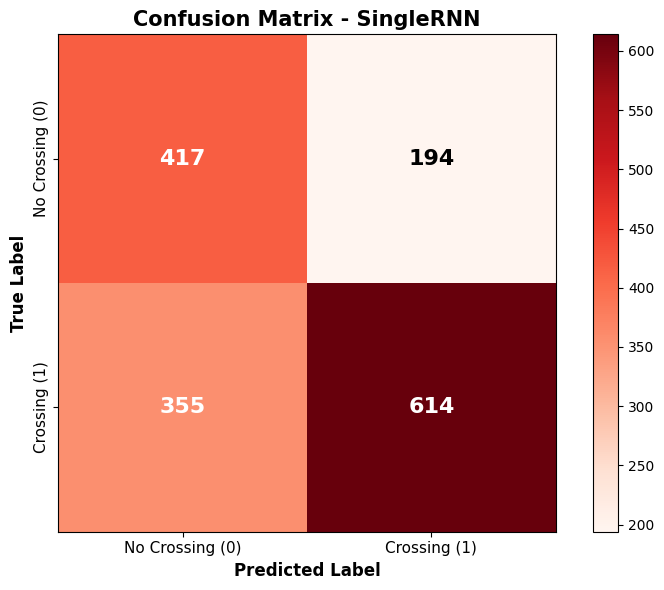

In [51]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'Reds' for RNN to distinguish from others
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds) 
    plt.title('Confusion Matrix - SingleRNN', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## SF-GRU

In [52]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
from tqdm.notebook import tqdm
import glob
import re
import cv2

# --- SF-GRU CONFIG (SPEED OPTIMIZED) ---
SFGRU_CONFIG = {
    'seq_len': 16,          
    'batch_size': 32,       # Good balance for GRU
    'img_size': (112, 112), # 112x112 for speed (4x faster than 224)
    'epochs': 10,
    'lr': 1e-4,
    'hidden_dim': 256,
    'gru_layers': 1,
    'model_save_dir': r'H:\DPJI\SFGRU',
    'device': CONFIG['device'],
    'num_workers': 0,       # Windows fix
    'stride': 8             # Fast epoch (skips redundancy)
}

os.makedirs(SFGRU_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ SF-GRU Config Loaded.\n   Resolution: {SFGRU_CONFIG['img_size']}\n   Batch Size: {SFGRU_CONFIG['batch_size']}")

✅ SF-GRU Config Loaded.
   Resolution: (112, 112)
   Batch Size: 32


In [53]:
# --- OPTIMIZED DATASET CLASS FOR SF-GRU ---
class OptimizedSFGRUDataset(Dataset):
    def __init__(self, img_dir, seq_len=16, stride=8, target_size=(112, 112)):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.target_size = target_size
        self.samples = [] 
        
        # 1. Group images
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        files.sort()
        
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            if len(frames) >= seq_len:
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: 
                img = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.uint8)
            else:
                # Fast Resize
                img = cv2.resize(img, self.target_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        
        # Shape: [Time, Channel, Height, Width]
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

print(f"🔄 Generating Optimized SF-GRU Dataset...")
sfgru_dataset = OptimizedSFGRUDataset(
    CONFIG['save_dir'], 
    seq_len=SFGRU_CONFIG['seq_len'], 
    stride=SFGRU_CONFIG['stride'],
    target_size=SFGRU_CONFIG['img_size']
)

# --- SPLITS ---
sfgru_labels = [s['label'] for s in sfgru_dataset.samples]
indices = np.arange(len(sfgru_dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=sfgru_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[sfgru_labels[i] for i in temp_idx], random_state=42)

# --- LOADERS ---
train_loader_sfgru = DataLoader(Subset(sfgru_dataset, train_idx), batch_size=SFGRU_CONFIG['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
val_loader_sfgru = DataLoader(Subset(sfgru_dataset, val_idx), batch_size=SFGRU_CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ SF-GRU Loaders Ready.\n   Train Samples: {len(train_idx)}\n   Val Samples: {len(val_idx)}")

🔄 Generating Optimized SF-GRU Dataset...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ SF-GRU Loaders Ready.
   Train Samples: 7371
   Val Samples: 1579


In [54]:
# --- MODEL DEFINITION: ResNet + GRU ---
class ResNetSFGRU(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=1, freeze_backbone=True):
        super(ResNetSFGRU, self).__init__()
        
        # 1. Feature Extractor (ResNet50)
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-1] # Remove FC
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        # Freeze Backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen.")
        
        # 2. GRU (Key difference from SingleRNN)
        self.gru = nn.GRU(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # 3. Classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Seq, C, H, W]
        b, seq, c, h, w = x.size()
        
        # Flatten time into batch for CNN: [Batch*Seq, C, H, W]
        c_in = x.view(b * seq, c, h, w)
        
        # Extract Features
        features = self.backbone(c_in) # [B*S, 2048, 1, 1]
        features = features.view(b, seq, -1) # [Batch, Seq, 2048]
        
        # GRU Pass
        # GRU returns: output, h_n
        gru_out, _ = self.gru(features)
        
        # Take last time step
        last_out = gru_out[:, -1, :] 
        
        # Classify
        return self.fc(last_out)

model_sfgru = ResNetSFGRU(
    hidden_dim=SFGRU_CONFIG['hidden_dim'],
    num_layers=SFGRU_CONFIG['gru_layers']
)
model_sfgru.to(SFGRU_CONFIG['device'])
print("✅ SF-GRU Model Initialized.")

❄️ ResNet Backbone Frozen.
✅ SF-GRU Model Initialized.


In [55]:
# --- HELPER FUNCTIONS ---
def train_one_epoch_sfgru(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False, mininterval=1.0)
    for batch in pbar:
        imgs = batch['images'].to(SFGRU_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(SFGRU_CONFIG['device'], non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

def validate_sfgru(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_list, lbls_list = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(SFGRU_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(SFGRU_CONFIG['device'], non_blocking=True).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            running_loss += loss.item()
            preds_list.extend(torch.sigmoid(logits).view(-1).cpu().numpy())
            lbls_list.extend(lbls.view(-1).cpu().numpy())
            
    preds_bin = (np.array(preds_list) > 0.5).astype(int)
    acc = accuracy_score(lbls_list, preds_bin)
    f1 = f1_score(lbls_list, preds_bin, zero_division=0)
    try: auc = roc_auc_score(lbls_list, preds_list)
    except: auc = 0.5
    
    return running_loss/len(loader), acc, f1, auc

In [56]:
# --- CELL 5: LOAD PRE-TRAINED SF-GRU MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
import numpy as np

# 1. Define Path
load_path = os.path.join(SFGRU_CONFIG['model_save_dir'], "best_sfgru.pth")

# 2. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained SF-GRU weights from: {load_path}")
    
    # Load state dict
    state_dict = torch.load(load_path, map_location=SFGRU_CONFIG['device'])
    model_sfgru.load_state_dict(state_dict)
    model_sfgru.eval()
    
    print("✅ Model weights loaded successfully.")

    # 3. Verify Performance on Validation Set
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion
    train_y = [sfgru_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(SFGRU_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Run Validation
    v_loss, v_acc, v_f1, v_auc = validate_sfgru(model_sfgru, val_loader_sfgru, criterion)
    
    print("-" * 40)
    print(f"🏆 Loaded SF-GRU Model Results:")
    print(f"   Val Loss: {v_loss:.4f}")
    print(f"   Accuracy: {v_acc:.4f}")
    print(f"   F1 Score: {v_f1:.4f}")
    print(f"   AUC:      {v_auc:.4f}")
    print("-" * 40)
    
    # 4. Re-init optimizer (needed if loading full checkpoint later)
    params_to_update = [p for p in model_sfgru.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=SFGRU_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path}'")
    print("⚠️ Please ensure the model file exists in H:\\DPJI\\SFGRU")

🔄 Loading pre-trained SF-GRU weights from: H:\DPJI\SFGRU\best_sfgru.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...
----------------------------------------
🏆 Loaded SF-GRU Model Results:
   Val Loss: 0.4714
   Accuracy: 0.6909
   F1 Score: 0.7674
   AUC:      0.7519
----------------------------------------


In [57]:
# --- LOAD CHECKPOINT ---
import os
import torch

LOAD_PATH = os.path.join(SFGRU_CONFIG['model_save_dir'], "full_checkpoint_sfgru.pth")

if os.path.exists(LOAD_PATH):
    print(f"🔄 Loading Checkpoint: {LOAD_PATH}")
    checkpoint = torch.load(LOAD_PATH, map_location=SFGRU_CONFIG['device'])
    
    # 1. Load Model
    model_sfgru.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Load Optimizer
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Optimizer state restored.")
    except Exception as e:
        print(f"⚠️ Could not load optimizer state: {e}")
        
    # 3. Metrics
    m = checkpoint.get('metrics', {})
    print("-" * 30)
    print(f"📊 Restored Metrics:")
    print(f"   • Best F1: {m.get('best_f1', 'N/A')}")
    print(f"   • Final AUC: {m.get('final_auc', 'N/A')}")
    print("-" * 30)
    
    model_sfgru.eval()

else:
    print(f"❌ Checkpoint not found at {LOAD_PATH}")

🔄 Loading Checkpoint: H:\DPJI\SFGRU\full_checkpoint_sfgru.pth
✅ Optimizer state restored.
------------------------------
📊 Restored Metrics:
   • Best F1: 0.7673975214489991
   • Final AUC: 0.7209037540814427
------------------------------


In [58]:
# --- CELL 7: CREATE SF-GRU TEST LOADER ---
# Use the test_idx generated in Cell 2
print(f"📂 Creating Test Loader for {len(test_idx)} sequences...")

test_loader_sfgru = DataLoader(
    Subset(sfgru_dataset, test_idx), 
    batch_size=SFGRU_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0, # Keep 0 for Windows
    pin_memory=True
)

print(f"✅ SF-GRU Test Loader Ready. Batches: {len(test_loader_sfgru)}")

📂 Creating Test Loader for 1580 sequences...
✅ SF-GRU Test Loader Ready. Batches: 50


In [59]:
# --- CELL 8: RUN TESTING ON SF-GRU TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_sfgru_testing(model, loader, device):
    print(f"🚀 Starting SF-GRU Inference on Test Set ({len(loader.dataset)} sequences)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True).unsqueeze(1)
            
            # Note: SF-GRU Model expects [Batch, Seq, C, H, W]
            # The OptimizedSFGRUDataset returns exactly this. No permute needed here.
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 SF-GRU FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_sfgru_testing(model_sfgru, test_loader_sfgru, SFGRU_CONFIG['device'])

🚀 Starting SF-GRU Inference on Test Set (1580 sequences)...


Testing:   0%|          | 0/50 [00:00<?, ?it/s]


🏆 SF-GRU FINAL TEST RESULTS (N=1580)
✅ Accuracy:      0.6785
✅ Precision:     0.7003
✅ Recall:        0.8318
✅ F1 Score:      0.7604
✅ ROC AUC:       0.7171
❌ Test Loss:     0.7874
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.62      0.44      0.51       611
    Crossing       0.70      0.83      0.76       969

    accuracy                           0.68      1580
   macro avg       0.66      0.63      0.64      1580
weighted avg       0.67      0.68      0.66      1580



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    266
Top-Right (False Alarm):         345
Bot-Left  (Missed Crossing):     163
Bot-Right (Crossing correct):    806


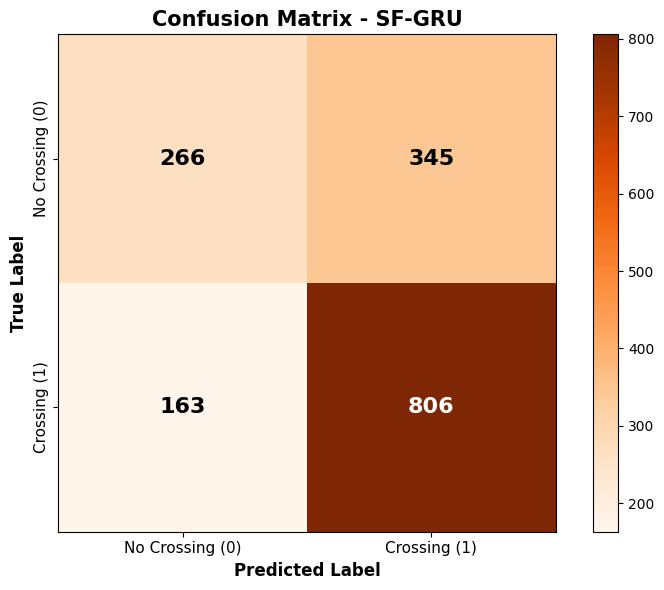

In [60]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'Oranges' for SF-GRU to distinguish from others
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges) 
    plt.title('Confusion Matrix - SF-GRU', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## PCPA

In [62]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
from tqdm.notebook import tqdm
import glob
import re
import cv2

# --- PCPA CONFIG (SPEED OPTIMIZED) ---
PCPA_CONFIG = {
    'seq_len': 16,          
    'batch_size': 32,       
    'img_size': (112, 112), # 112x112 for speed
    'epochs': 10,
    'lr': 1e-4,
    'hidden_dim': 256,
    'attention_dim': 128,   # Dimension for attention calculation
    'model_save_dir': r'H:\DPJI\PCPA',
    'device': CONFIG['device'],
    'num_workers': 0,       # Windows fix
    'stride': 8             # Fast epoch
}

os.makedirs(PCPA_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ PCPA Config Loaded.\n   Resolution: {PCPA_CONFIG['img_size']}\n   Batch Size: {PCPA_CONFIG['batch_size']}")

✅ PCPA Config Loaded.
   Resolution: (112, 112)
   Batch Size: 32


In [63]:
# --- OPTIMIZED DATASET CLASS FOR PCPA ---
class OptimizedPCPADataset(Dataset):
    def __init__(self, img_dir, seq_len=16, stride=8, target_size=(112, 112)):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.target_size = target_size
        self.samples = [] 
        
        # 1. Group images
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        files.sort()
        
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            if len(frames) >= seq_len:
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: 
                img = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.uint8)
            else:
                # Fast Resize
                img = cv2.resize(img, self.target_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        
        # Shape: [Time, Channel, Height, Width]
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

print(f"🔄 Generating Optimized PCPA Dataset...")
pcpa_dataset = OptimizedPCPADataset(
    CONFIG['save_dir'], 
    seq_len=PCPA_CONFIG['seq_len'], 
    stride=PCPA_CONFIG['stride'],
    target_size=PCPA_CONFIG['img_size']
)

# --- SPLITS ---
pcpa_labels = [s['label'] for s in pcpa_dataset.samples]
indices = np.arange(len(pcpa_dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=pcpa_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[pcpa_labels[i] for i in temp_idx], random_state=42)

# --- LOADERS ---
train_loader_pcpa = DataLoader(Subset(pcpa_dataset, train_idx), batch_size=PCPA_CONFIG['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
val_loader_pcpa = DataLoader(Subset(pcpa_dataset, val_idx), batch_size=PCPA_CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ PCPA Loaders Ready.\n   Train Samples: {len(train_idx)}\n   Val Samples: {len(val_idx)}")

🔄 Generating Optimized PCPA Dataset...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ PCPA Loaders Ready.
   Train Samples: 7371
   Val Samples: 1579


In [64]:
# --- MODEL DEFINITION: ResNet + Temporal Attention (PCPA Context) ---
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim, attention_dim):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1)
        )

    def forward(self, x):
        # x: [Batch, Seq_Len, Feature_Dim]
        # weights: [Batch, Seq_Len, 1]
        weights = self.attn(x)
        weights = F.softmax(weights, dim=1)
        
        # Context vector: Weighted sum of features
        # [Batch, Feature_Dim]
        context = torch.sum(x * weights, dim=1)
        return context, weights

class ResNetPCPA(nn.Module):
    def __init__(self, hidden_dim=256, attention_dim=128, freeze_backbone=True):
        super(ResNetPCPA, self).__init__()
        
        # 1. Feature Extractor (ResNet50)
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-1] 
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen.")
            
        # 2. Dimensionality Reduction (Optional but good for Attention)
        self.pre_attn_fc = nn.Linear(self.feature_dim, hidden_dim)
        
        # 3. Temporal Attention Module
        self.attention = TemporalAttention(hidden_dim, attention_dim)
        
        # 4. Classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [Batch, Seq, C, H, W]
        b, seq, c, h, w = x.size()
        
        # CNN Pass
        c_in = x.view(b * seq, c, h, w)
        features = self.backbone(c_in) 
        features = features.view(b, seq, -1) # [Batch, Seq, 2048]
        
        # Reduce dim for Attention logic
        features = F.relu(self.pre_attn_fc(features)) # [Batch, Seq, Hidden]
        
        # Attention Pass
        context, _ = self.attention(features) # [Batch, Hidden]
        
        # Classification
        return self.fc(context)

model_pcpa = ResNetPCPA(
    hidden_dim=PCPA_CONFIG['hidden_dim'],
    attention_dim=PCPA_CONFIG['attention_dim']
)
model_pcpa.to(PCPA_CONFIG['device'])
print("✅ PCPA (Visual Attention) Model Initialized.")

❄️ ResNet Backbone Frozen.
✅ PCPA (Visual Attention) Model Initialized.


In [65]:
# --- HELPER FUNCTIONS ---
def train_one_epoch_pcpa(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False, mininterval=1.0)
    for batch in pbar:
        imgs = batch['images'].to(PCPA_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(PCPA_CONFIG['device'], non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

def validate_pcpa(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_list, lbls_list = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(PCPA_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(PCPA_CONFIG['device'], non_blocking=True).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            running_loss += loss.item()
            preds_list.extend(torch.sigmoid(logits).view(-1).cpu().numpy())
            lbls_list.extend(lbls.view(-1).cpu().numpy())
            
    preds_bin = (np.array(preds_list) > 0.5).astype(int)
    acc = accuracy_score(lbls_list, preds_bin)
    f1 = f1_score(lbls_list, preds_bin, zero_division=0)
    try: auc = roc_auc_score(lbls_list, preds_list)
    except: auc = 0.5
    
    return running_loss/len(loader), acc, f1, auc

In [66]:
# --- CELL 5: LOAD PRE-TRAINED PCPA MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
import numpy as np

# 1. Define Path
load_path = os.path.join(PCPA_CONFIG['model_save_dir'], "best_pcpa.pth")

# 2. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained PCPA weights from: {load_path}")
    
    # Load state dict
    state_dict = torch.load(load_path, map_location=PCPA_CONFIG['device'])
    model_pcpa.load_state_dict(state_dict)
    model_pcpa.eval()
    
    print("✅ Model weights loaded successfully.")

    # 3. Verify Performance on Validation Set
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion
    train_y = [pcpa_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(PCPA_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Run Validation
    v_loss, v_acc, v_f1, v_auc = validate_pcpa(model_pcpa, val_loader_pcpa, criterion)
    
    print("-" * 40)
    print(f"🏆 Loaded PCPA Model Results:")
    print(f"   Val Loss: {v_loss:.4f}")
    print(f"   Accuracy: {v_acc:.4f}")
    print(f"   F1 Score: {v_f1:.4f}")
    print(f"   AUC:      {v_auc:.4f}")
    print("-" * 40)
    
    # 4. Re-init optimizer (for future compatibility)
    params_to_update = [p for p in model_pcpa.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=PCPA_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path}'")
    print("⚠️ Please ensure the model file exists in H:\\DPJI\\PCPA")

🔄 Loading pre-trained PCPA weights from: H:\DPJI\PCPA\best_pcpa.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...
----------------------------------------
🏆 Loaded PCPA Model Results:
   Val Loss: 0.4871
   Accuracy: 0.6662
   F1 Score: 0.7216
   AUC:      0.7047
----------------------------------------


In [67]:
# --- LOAD CHECKPOINT ---
import os
import torch

LOAD_PATH = os.path.join(PCPA_CONFIG['model_save_dir'], "full_checkpoint_pcpa.pth")

if os.path.exists(LOAD_PATH):
    print(f"🔄 Loading Checkpoint: {LOAD_PATH}")
    checkpoint = torch.load(LOAD_PATH, map_location=PCPA_CONFIG['device'])
    
    # 1. Load Model
    model_pcpa.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Load Optimizer
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Optimizer state restored.")
    except Exception as e:
        print(f"⚠️ Could not load optimizer state: {e}")
        
    # 3. Metrics
    m = checkpoint.get('metrics', {})
    print("-" * 30)
    print(f"📊 Restored Metrics:")
    print(f"   • Best F1: {m.get('best_f1', 'N/A')}")
    print(f"   • Final AUC: {m.get('final_auc', 'N/A')}")
    print("-" * 30)
    
    model_pcpa.eval()

else:
    print(f"❌ Checkpoint not found at {LOAD_PATH}")

🔄 Loading Checkpoint: H:\DPJI\PCPA\full_checkpoint_pcpa.pth
✅ Optimizer state restored.
------------------------------
📊 Restored Metrics:
   • Best F1: 0.7216059165346012
   • Final AUC: 0.6904244700468625
------------------------------


In [68]:
# --- CELL 7: CREATE PCPA TEST LOADER ---
# Use the test_idx generated in Cell 2
print(f"📂 Creating Test Loader for {len(test_idx)} sequences...")

test_loader_pcpa = DataLoader(
    Subset(pcpa_dataset, test_idx), 
    batch_size=PCPA_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0, # Keep 0 for Windows
    pin_memory=True
)

print(f"✅ PCPA Test Loader Ready. Batches: {len(test_loader_pcpa)}")

📂 Creating Test Loader for 1580 sequences...
✅ PCPA Test Loader Ready. Batches: 50


In [69]:
# --- CELL 8: RUN TESTING ON PCPA TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_pcpa_testing(model, loader, device):
    print(f"🚀 Starting PCPA Inference on Test Set ({len(loader.dataset)} sequences)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True).unsqueeze(1)
            
            # PCPA Model expects [Batch, Seq, C, H, W]
            # No permute needed.
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 PCPA FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_pcpa_testing(model_pcpa, test_loader_pcpa, PCPA_CONFIG['device'])

🚀 Starting PCPA Inference on Test Set (1580 sequences)...


Testing:   0%|          | 0/50 [00:00<?, ?it/s]


🏆 PCPA FINAL TEST RESULTS (N=1580)
✅ Accuracy:      0.6203
✅ Precision:     0.7071
✅ Recall:        0.6502
✅ F1 Score:      0.6774
✅ ROC AUC:       0.6460
❌ Test Loss:     0.7077
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.51      0.57      0.54       611
    Crossing       0.71      0.65      0.68       969

    accuracy                           0.62      1580
   macro avg       0.61      0.61      0.61      1580
weighted avg       0.63      0.62      0.62      1580



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    350
Top-Right (False Alarm):         261
Bot-Left  (Missed Crossing):     339
Bot-Right (Crossing correct):    630


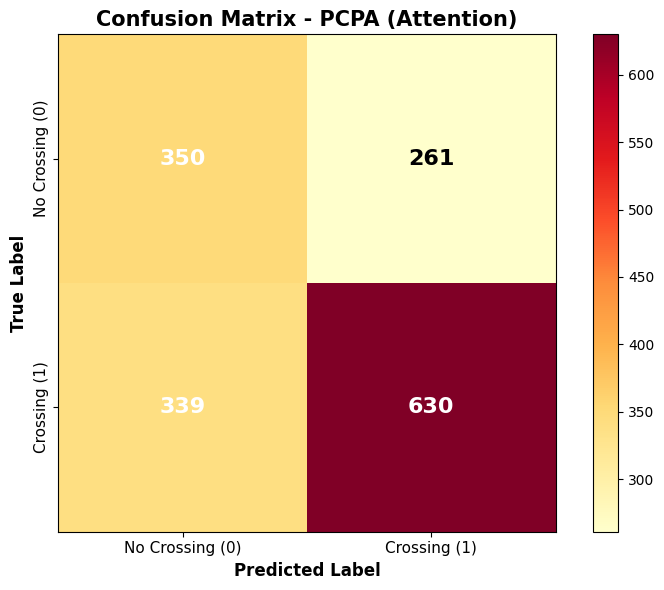

In [70]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'YlOrRd' (Yellow-Orange-Red) for PCPA (Attention warmth)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.YlOrRd) 
    plt.title('Confusion Matrix - PCPA (Attention)', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## MaskPCPA

In [71]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
from tqdm.notebook import tqdm
import glob
import re
import cv2

# --- MASK-PCPA CONFIG (SPEED OPTIMIZED) ---
MASKPCPA_CONFIG = {
    'seq_len': 16,          
    'batch_size': 32,       
    'img_size': (112, 112), # 112x112 for speed
    'epochs': 10,
    'lr': 1e-4,
    'hidden_dim': 256,
    'attention_dim': 128,
    'model_save_dir': r'H:\DPJI\MaskPCPA',
    'device': CONFIG['device'],
    'num_workers': 0,       # Windows fix
    'stride': 8             # Fast epoch
}

os.makedirs(MASKPCPA_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ MaskPCPA Config Loaded.\n   Resolution: {MASKPCPA_CONFIG['img_size']}\n   Batch Size: {MASKPCPA_CONFIG['batch_size']}")

✅ MaskPCPA Config Loaded.
   Resolution: (112, 112)
   Batch Size: 32


In [72]:
# --- OPTIMIZED DATASET CLASS FOR MASK-PCPA ---
class OptimizedMaskPCPADataset(Dataset):
    def __init__(self, img_dir, seq_len=16, stride=8, target_size=(112, 112)):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.target_size = target_size
        self.samples = [] 
        
        # 1. Group images
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        files.sort()
        
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            if len(frames) >= seq_len:
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: 
                img = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.uint8)
            else:
                img = cv2.resize(img, self.target_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        
        # Shape: [Time, Channel, Height, Width]
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

print(f"🔄 Generating Optimized MaskPCPA Dataset...")
maskpcpa_dataset = OptimizedMaskPCPADataset(
    CONFIG['save_dir'], 
    seq_len=MASKPCPA_CONFIG['seq_len'], 
    stride=MASKPCPA_CONFIG['stride'],
    target_size=MASKPCPA_CONFIG['img_size']
)

# --- SPLITS ---
mpcpa_labels = [s['label'] for s in maskpcpa_dataset.samples]
indices = np.arange(len(maskpcpa_dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=mpcpa_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[mpcpa_labels[i] for i in temp_idx], random_state=42)

# --- LOADERS ---
train_loader_mpcpa = DataLoader(Subset(maskpcpa_dataset, train_idx), batch_size=MASKPCPA_CONFIG['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
val_loader_mpcpa = DataLoader(Subset(maskpcpa_dataset, val_idx), batch_size=MASKPCPA_CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ MaskPCPA Loaders Ready.\n   Train Samples: {len(train_idx)}\n   Val Samples: {len(val_idx)}")

🔄 Generating Optimized MaskPCPA Dataset...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ MaskPCPA Loaders Ready.
   Train Samples: 7371
   Val Samples: 1579


In [73]:
# --- MODEL DEFINITION: MaskPCPA (Spatial Mask + Temporal Attention) ---

class SpatialMaskAttention(nn.Module):
    """
    Learns a spatial mask to focus on the pedestrian within the 2D feature map.
    """
    def __init__(self, in_channels):
        super(SpatialMaskAttention, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [Batch*Seq, C, H, W]
        # mask: [Batch*Seq, 1, H, W]
        mask = self.sigmoid(self.conv(x))
        # Apply mask
        return x * mask

class TemporalAttention(nn.Module):
    def __init__(self, feature_dim, attention_dim):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1)
        )

    def forward(self, x):
        weights = F.softmax(self.attn(x), dim=1)
        context = torch.sum(x * weights, dim=1)
        return context

class ResNetMaskPCPA(nn.Module):
    def __init__(self, hidden_dim=256, attention_dim=128, freeze_backbone=True):
        super(ResNetMaskPCPA, self).__init__()
        
        # 1. Backbone
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-2] # Remove FC AND AvgPool (keep spatial dims)
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen.")
            
        # 2. Spatial Mask Module
        self.spatial_attn = SpatialMaskAttention(self.feature_dim)
        
        # 3. Global Pooling (to flatten after masking)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 4. Dimensionality Reduction
        self.pre_attn_fc = nn.Linear(self.feature_dim, hidden_dim)
        
        # 5. Temporal Attention
        self.temporal_attn = TemporalAttention(hidden_dim, attention_dim)
        
        # 6. Classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [Batch, Seq, C, H, W]
        b, seq, c, h, w = x.size()
        
        # Collapse time
        c_in = x.view(b * seq, c, h, w)
        
        # Get Spatial Features: [B*S, 2048, H_feat, W_feat]
        features_map = self.backbone(c_in)
        
        # Apply Spatial Mask (Learn where the pedestrian is)
        masked_features = self.spatial_attn(features_map)
        
        # Pool to vector: [B*S, 2048, 1, 1] -> [B*S, 2048]
        features_vec = self.avg_pool(masked_features).flatten(1)
        
        # Reshape to Sequence: [Batch, Seq, 2048]
        features_seq = features_vec.view(b, seq, -1)
        
        # Reduce Dim: [Batch, Seq, Hidden]
        features_seq = F.relu(self.pre_attn_fc(features_seq))
        
        # Temporal Attention (Focus on key frames)
        context = self.temporal_attn(features_seq)
        
        # Classify
        return self.fc(context)

model_mpcpa = ResNetMaskPCPA(
    hidden_dim=MASKPCPA_CONFIG['hidden_dim'],
    attention_dim=MASKPCPA_CONFIG['attention_dim']
)
model_mpcpa.to(MASKPCPA_CONFIG['device'])
print("✅ MaskPCPA Model Initialized.")

❄️ ResNet Backbone Frozen.
✅ MaskPCPA Model Initialized.


In [74]:
# --- HELPER FUNCTIONS ---
def train_one_epoch_mpcpa(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False, mininterval=1.0)
    for batch in pbar:
        imgs = batch['images'].to(MASKPCPA_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(MASKPCPA_CONFIG['device'], non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

def validate_mpcpa(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_list, lbls_list = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(MASKPCPA_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(MASKPCPA_CONFIG['device'], non_blocking=True).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            running_loss += loss.item()
            preds_list.extend(torch.sigmoid(logits).view(-1).cpu().numpy())
            lbls_list.extend(lbls.view(-1).cpu().numpy())
            
    preds_bin = (np.array(preds_list) > 0.5).astype(int)
    acc = accuracy_score(lbls_list, preds_bin)
    f1 = f1_score(lbls_list, preds_bin, zero_division=0)
    try: auc = roc_auc_score(lbls_list, preds_list)
    except: auc = 0.5
    
    return running_loss/len(loader), acc, f1, auc

In [75]:
# --- CELL 5: LOAD PRE-TRAINED MASK-PCPA MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
import numpy as np

# 1. Define Path
load_path = os.path.join(MASKPCPA_CONFIG['model_save_dir'], "best_mpcpa.pth")

# 2. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained MaskPCPA weights from: {load_path}")
    
    # Load state dict
    state_dict = torch.load(load_path, map_location=MASKPCPA_CONFIG['device'])
    model_mpcpa.load_state_dict(state_dict)
    model_mpcpa.eval()
    
    print("✅ Model weights loaded successfully.")

    # 3. Verify Performance on Validation Set
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion
    train_y = [mpcpa_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(MASKPCPA_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Run Validation
    v_loss, v_acc, v_f1, v_auc = validate_mpcpa(model_mpcpa, val_loader_mpcpa, criterion)
    
    print("-" * 40)
    print(f"🏆 Loaded MaskPCPA Model Results:")
    print(f"   Val Loss: {v_loss:.4f}")
    print(f"   Accuracy: {v_acc:.4f}")
    print(f"   F1 Score: {v_f1:.4f}")
    print(f"   AUC:      {v_auc:.4f}")
    print("-" * 40)
    
    # 4. Re-init optimizer (needed for compatibility with checkpoint loading)
    params_to_update = [p for p in model_mpcpa.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=MASKPCPA_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path}'")
    print("⚠️ Please ensure the model file exists in H:\\DPJI\\MaskPCPA")

🔄 Loading pre-trained MaskPCPA weights from: H:\DPJI\MaskPCPA\best_mpcpa.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...
----------------------------------------
🏆 Loaded MaskPCPA Model Results:
   Val Loss: 0.4902
   Accuracy: 0.6675
   F1 Score: 0.7278
   AUC:      0.7052
----------------------------------------


In [76]:
# --- CELL 7: CREATE MASK-PCPA TEST LOADER ---
# Use the test_idx generated in Cell 2
print(f"📂 Creating Test Loader for {len(test_idx)} sequences...")

test_loader_mpcpa = DataLoader(
    Subset(maskpcpa_dataset, test_idx), 
    batch_size=MASKPCPA_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=0, # Keep 0 for Windows
    pin_memory=True
)

print(f"✅ MaskPCPA Test Loader Ready. Batches: {len(test_loader_mpcpa)}")

📂 Creating Test Loader for 1580 sequences...
✅ MaskPCPA Test Loader Ready. Batches: 50


In [77]:
# --- CELL 8: RUN TESTING ON MASK-PCPA TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_mpcpa_testing(model, loader, device):
    print(f"🚀 Starting MaskPCPA Inference on Test Set ({len(loader.dataset)} sequences)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset gives: [Batch, Seq, C, H, W]
            imgs = batch['images'].to(device, non_blocking=True)
            lbls = batch['label'].to(device, non_blocking=True).unsqueeze(1)
            
            # MaskPCPA Model expects [Batch, Seq, C, H, W]
            # No permute needed.
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 MASK-PCPA FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_mpcpa_testing(model_mpcpa, test_loader_mpcpa, MASKPCPA_CONFIG['device'])

🚀 Starting MaskPCPA Inference on Test Set (1580 sequences)...


Testing:   0%|          | 0/50 [00:00<?, ?it/s]


🏆 MASK-PCPA FINAL TEST RESULTS (N=1580)
✅ Accuracy:      0.6380
✅ Precision:     0.7061
✅ Recall:        0.7018
✅ F1 Score:      0.7039
✅ ROC AUC:       0.6653
❌ Test Loss:     0.6513
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.53      0.54      0.53       611
    Crossing       0.71      0.70      0.70       969

    accuracy                           0.64      1580
   macro avg       0.62      0.62      0.62      1580
weighted avg       0.64      0.64      0.64      1580



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    328
Top-Right (False Alarm):         283
Bot-Left  (Missed Crossing):     289
Bot-Right (Crossing correct):    680


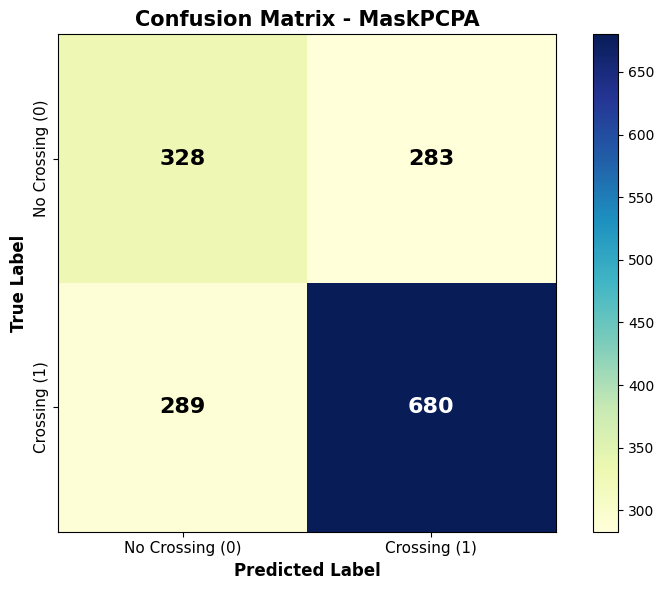

In [78]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'YlGnBu' (Yellow-Green-Blue) for MaskPCPA
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.YlGnBu) 
    plt.title('Confusion Matrix - MaskPCPA', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)

## Static

In [79]:
import os
import glob
import cv2
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import xml.etree.ElementTree as ET
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from decord import VideoReader, cpu
import torchvision.models as models

# --- GLOBAL CONFIG ---
CONFIG = {
    # Path settings
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'ped_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'save_dir': r'H:\DPJI\fast_data_static_v2', 
    'model_save_dir': r'H:\DPJI\Static',        # <--- Explicit Model Path
    
    # Training settings
    'img_size': (224, 224),
    'subsample_rate': 5,     
    'batch_size': 8,
    'lr': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Ensure directory exists
os.makedirs(CONFIG['model_save_dir'], exist_ok=True)

print(f"✅ Configuration Loaded. Device: {CONFIG['device']}")
print(f"📂 Model Path: {CONFIG['model_save_dir']}")

✅ Configuration Loaded. Device: cuda
📂 Model Path: H:\DPJI\Static


In [80]:
# --- 1. Metadata Parser (Robust) ---
def parse_metadata_robust(video_file, ped_xml):
    samples = []
    if not os.path.exists(ped_xml): return []
    
    try:
        tree = ET.parse(ped_xml)
        root = tree.getroot()
        
        # Universal set of values that indicate "Crossing"
        CROSSING_VALUES = {
            'cu', 'crossing_undesignated', 'jaywalking',
            'cfu', 'crossing_fast_undesignated', 'jaywalkingfast',
            'cd', 'crossing_designated', 'crossing',
            'cfd', 'crossing_fast_designated', 'crossingfast',
            'ci', 'crossing_irrelevant',
            'yes', 'true', '1'
        }

        for track in root.findall('track'):
            if track.attrib.get('label') != 'pedestrian': continue
            
            for box in track.findall('box'):
                # Skip fully occluded
                if box.attrib.get('occlusion') == '2': continue 
                
                # Check for Crossing Label
                is_crossing = False
                box_values = set()
                
                # Check sub-attributes
                for attr in box.findall('attribute'):
                    if attr.text: box_values.add(str(attr.text).lower().strip())
                # Check box attributes
                for k, v in box.attrib.items():
                    if k not in ['xtl', 'ytl', 'xbr', 'ybr', 'frame']:
                        box_values.add(str(v).lower().strip())
                
                # Match
                if not box_values.isdisjoint(CROSSING_VALUES):
                    is_crossing = True
                if box.attrib.get('crossing') in ['yes', '1', 'true']:
                    is_crossing = True

                # Save Sample Info
                samples.append({
                    'frame': int(box.attrib['frame']),
                    'bbox': [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']],
                    'label': 1.0 if is_crossing else 0.0
                })
                
    except Exception as e:
        print(f"Error parsing {ped_xml}: {e}")
        
    return samples

# --- 2. Generator Function ---
def generate_fast_dataset():
    if os.path.exists(CONFIG['save_dir']) and len(os.listdir(CONFIG['save_dir'])) > 100:
        print(f"⚠️ Folder {CONFIG['save_dir']} already has data. Skipping generation.")
        return

    print("🚀 Starting Data Generation...")
    os.makedirs(CONFIG['save_dir'], exist_ok=True)
    
    tasks = []
    # Collect videos
    for set_name in os.listdir(CONFIG['videos_root']):
        vid_dir = os.path.join(CONFIG['videos_root'], set_name)
        if not os.path.isdir(vid_dir): continue
        
        for v in os.listdir(vid_dir):
            if v.lower().endswith('.mp4') and not v.startswith('._'):
                full_vid = os.path.join(vid_dir, v)
                full_xml = os.path.join(CONFIG['ped_xml_root'], set_name, os.path.splitext(v)[0] + '.xml')
                if os.path.exists(full_xml):
                    tasks.append((full_vid, full_xml))

    saved, pos, neg = 0, 0, 0
    
    for vid_path, xml_path in tqdm(tasks, desc="Processing Videos"):
        samples = parse_metadata_robust(vid_path, xml_path)
        if not samples: continue
            
        try:
            vr = VideoReader(vid_path, ctx=cpu(0))
            for i, item in enumerate(samples):
                if i % CONFIG['subsample_rate'] != 0: continue # Subsample
                
                frame_idx = item['frame']
                if frame_idx >= len(vr): continue
                
                # Crop & Save
                frame = vr[frame_idx].asnumpy()
                h, w, _ = frame.shape
                x1, y1, x2, y2 = map(int, item['bbox'])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)
                
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0: continue
                
                crop = cv2.resize(crop, CONFIG['img_size'])
                crop = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
                
                vid_name = os.path.splitext(os.path.basename(vid_path))[0]
                save_name = f"{vid_name}_{frame_idx}_{item['label']}.jpg"
                
                cv2.imwrite(os.path.join(CONFIG['save_dir'], save_name), crop)
                saved += 1
                if item['label'] == 1.0: pos += 1
                else: neg += 1
                
        except Exception: pass

    print(f"✅ Generated {saved} images.")
    print(f"   Crossing: {pos} | No-Crossing: {neg}")

# --- EXECUTE GENERATION ---
generate_fast_dataset()

⚠️ Folder H:\DPJI\fast_data_static_v2 already has data. Skipping generation.


In [81]:
class FastStaticDataset(Dataset):
    def __init__(self, metadata_list):
        self.metadata = metadata_list
        # Cache labels for stratified split
        self.labels = [item['label'] for item in metadata_list] 
        
    def __len__(self): return len(self.metadata)
    
    def __getitem__(self, idx):
        item = self.metadata[idx]
        img = cv2.imread(item['img_path'])
        if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Norm 0-1 and Channel First
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return {
            'images': img_tensor.unsqueeze(0), # Add Seq dim [1, C, H, W]
            'label': torch.tensor(item['label']).float()
        }

# --- BUILD INDEX ---
image_files = glob.glob(os.path.join(CONFIG['save_dir'], "*.jpg"))
metadata = []
label_pattern = re.compile(r"_([0-9]+\.?[0-9]*)\.jpg$")

print(f"📂 Indexing {len(image_files)} files from {CONFIG['save_dir']}...")
for img_path in tqdm(image_files):
    match = label_pattern.search(os.path.basename(img_path))
    if match:
        lbl = float(match.group(1))
        lbl = 1.0 if lbl > 0.5 else 0.0
        metadata.append({'img_path': img_path, 'label': lbl})

fast_dataset = FastStaticDataset(metadata)
print(f"✅ Dataset Ready: {len(fast_dataset)} samples.")

📂 Indexing 84627 files from H:\DPJI\fast_data_static_v2...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Dataset Ready: 84627 samples.


In [82]:
# --- STRATIFIED SPLIT ---
indices = np.arange(len(fast_dataset))
labels = fast_dataset.labels

if len(labels) < 10:
    print("⚠️ Too few samples. Using dummy split.")
    train_idx, val_idx, test_idx = indices, indices, indices
else:
    # 70% Train, 15% Val, 15% Test
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

train_loader = DataLoader(Subset(fast_dataset, train_idx), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(Subset(fast_dataset, val_idx), batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(Subset(fast_dataset, test_idx), batch_size=CONFIG['batch_size'], shuffle=False)

print(f"✅ Splits: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")

✅ Splits: Train=59238, Val=12694, Test=12695


In [83]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for i, batch in enumerate(pbar):
        imgs = batch['images'].to(CONFIG['device']).squeeze(1) # [B, C, H, W]
        lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (i+1)})
        
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_lbls = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(CONFIG['device']).squeeze(1)
            lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
            
    preds = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_lbls, preds)
    f1 = f1_score(all_lbls, preds, zero_division=0)
    try: auc = roc_auc_score(all_lbls, all_preds)
    except: auc = 0.5
        
    return total_loss/len(loader), acc, f1, auc

In [84]:
# --- MODEL SETUP & LOADING ---
# 1. Define Architecture (Must match the trained model)
model = models.resnet50(weights=None) # No need to download ImageNet weights
model.fc = nn.Linear(2048, 1) 
model.to(CONFIG['device'])

# 2. Define Path
load_path = os.path.join(CONFIG['model_save_dir'], "best_model.pth")

# 3. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained weights from: {load_path}")
    state_dict = torch.load(load_path, map_location=CONFIG['device'])
    model.load_state_dict(state_dict)
    model.eval()
    print("✅ Model weights loaded successfully.")
else:
    raise FileNotFoundError(f"❌ Could not find model at {load_path}")

# 4. Setup Criterion (Needed for evaluation metrics)
# Re-calculate weights just for consistency with evaluation logic
train_y = [fast_dataset.labels[i] for i in train_idx]
pos = sum(train_y)
neg = len(train_y) - pos
pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(CONFIG['device'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 5. Verify Performance (Run Evaluation Only)
print("🚀 Verifying model performance on Validation Set...")
v_loss, v_acc, v_f1, v_auc = evaluate(model, val_loader, criterion)

print("-" * 40)
print(f"🏆 Loaded Model Results:")
print(f"   Val Loss: {v_loss:.4f}")
print(f"   Accuracy: {v_acc:.4f}")
print(f"   F1 Score: {v_f1:.4f}")
print(f"   AUC:      {v_auc:.4f}")
print("-" * 40)

# Needed for Cell 8 to bundle the optimizer state (even if not stepping)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

🔄 Loading pre-trained weights from: H:\DPJI\Static\best_model.pth
✅ Model weights loaded successfully.
🚀 Verifying model performance on Validation Set...
----------------------------------------
🏆 Loaded Model Results:
   Val Loss: 0.3893
   Accuracy: 0.7917
   F1 Score: 0.8335
   AUC:      0.8736
----------------------------------------


In [85]:
# --- CELL 8: LOAD EXISTING CHECKPOINT ---
import os
import torch

# 1. Define Path to the existing checkpoint
CHECKPOINT_PATH = os.path.join(CONFIG['model_save_dir'], "full_checkpoint.pth")

if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Found checkpoint at: {CHECKPOINT_PATH}")
    print("   Loading state dictionaries...")
    
    # 2. Load the file
    # map_location ensures it loads to the correct device (cuda/cpu)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=CONFIG['device'])
    
    # 3. Apply states to Model and Optimizer
    # (Note: 'model' and 'optimizer' must be defined in Cell 6 before running this)
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Model and Optimizer states restored successfully.")
    except KeyError as e:
        print(f"⚠️ Key Error loading state dicts: {e}")
    except RuntimeError as e:
        print(f"⚠️ Runtime Error (Shape Mismatch?): {e}")

    # 4. Display Stored Metrics (if available)
    if 'metrics' in checkpoint:
        m = checkpoint['metrics']
        print("-" * 30)
        print(f"📊 Stored Performance Metrics:")
        print(f"   • Val Loss: {m.get('val_loss', 'N/A')}")
        print(f"   • Accuracy: {m.get('val_acc', 'N/A')}")
        print(f"   • F1 Score: {m.get('val_f1', 'N/A')}")
        print(f"   • AUC:      {m.get('val_auc', 'N/A')}")
        print("-" * 30)
    else:
        print("ℹ️ No metrics dictionary found in checkpoint.")

else:
    print(f"❌ Error: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("   Please ensure the file exists in H:\\DPJI\\Static")

🔄 Found checkpoint at: H:\DPJI\Static\full_checkpoint.pth
   Loading state dictionaries...
✅ Model and Optimizer states restored successfully.
------------------------------
📊 Stored Performance Metrics:
   • Val Loss: 0.3893311552509135
   • Accuracy: 0.791712620135497
   • F1 Score: 0.8335222264198464
   • AUC:      0.8735988058804556
------------------------------


In [86]:
# --- CELL 8: RUN TESTING ON TEST SPLIT ---
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    classification_report
)
import numpy as np
import torch.nn as nn

def run_static_testing(model, loader, device):
    print(f"🚀 Starting Static Inference on Test Set ({len(loader.dataset)} images)...")
    model.eval()
    
    all_probs = []
    all_targets = []
    test_loss = 0.0
    
    # Criterion for loss calculation context
    criterion_test = nn.BCEWithLogitsLoss() 

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            # 1. Prepare Data
            # Dataset returns [B, 1, C, H, W] due to unsqueeze in __getitem__
            # We need [B, C, H, W] for standard ResNet
            imgs = batch['images'].to(device).squeeze(1) 
            lbls = batch['label'].to(device).unsqueeze(1)
            
            # 2. Forward Pass
            logits = model(imgs) # Output: [Batch, 1]
            loss = criterion_test(logits, lbls)
            
            # 3. Collect Data
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = lbls.cpu().numpy()
            
            # Flatten arrays
            all_probs.extend(probs.flatten())
            all_targets.extend(targets.flatten())

    # --- METRICS CALCULATION ---
    y_prob = np.array(all_probs)
    y_true = np.array(all_targets)
    
    # Binarize predictions (Threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5 

    print("\n" + "="*45)
    print(f"🏆 STATIC FINAL TEST RESULTS (N={len(y_true)})")
    print("="*45)
    print(f"✅ Accuracy:      {acc:.4f}")
    print(f"✅ Precision:     {prec:.4f}")
    print(f"✅ Recall:        {rec:.4f}")
    print(f"✅ F1 Score:      {f1:.4f}")
    print(f"✅ ROC AUC:       {auc:.4f}")
    print(f"❌ Test Loss:     {test_loss / len(loader):.4f}")
    print("-" * 45)
    print("📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crossing', 'Crossing']))
    
    return y_true, y_pred, y_prob

# Execute Testing
y_true, y_pred, y_prob = run_static_testing(model, test_loader, CONFIG['device'])

🚀 Starting Static Inference on Test Set (12695 images)...


Testing:   0%|          | 0/1587 [00:00<?, ?it/s]


🏆 STATIC FINAL TEST RESULTS (N=12695)
✅ Accuracy:      0.7807
✅ Precision:     0.8130
✅ Recall:        0.8371
✅ F1 Score:      0.8249
✅ ROC AUC:       0.8641
❌ Test Loss:     0.4907
---------------------------------------------
📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Crossing       0.72      0.69      0.71      4861
    Crossing       0.81      0.84      0.82      7834

    accuracy                           0.78     12695
   macro avg       0.77      0.76      0.77     12695
weighted avg       0.78      0.78      0.78     12695



📉 RAW CONFUSION MATRIX VALUES:
Top-Left  (No Cross correct):    3353
Top-Right (False Alarm):         1508
Bot-Left  (Missed Crossing):     1276
Bot-Right (Crossing correct):    6558


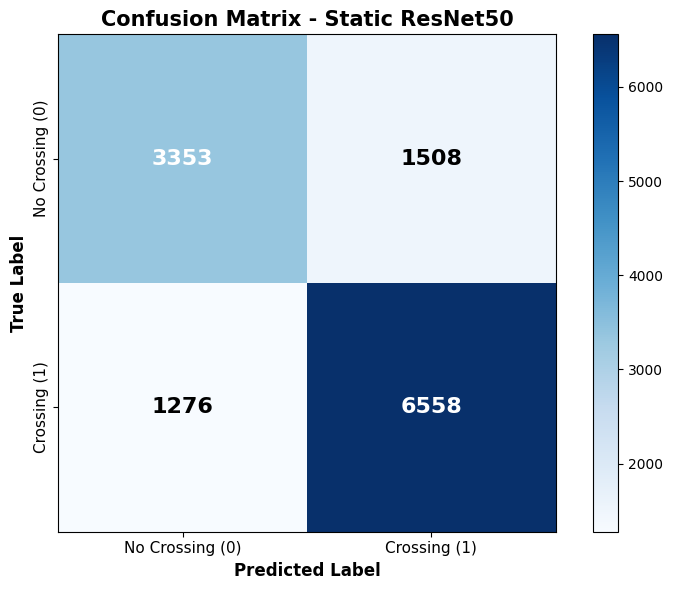

In [87]:
# --- CELL 9: VISUALIZE CONFUSION MATRIX (Robust) ---
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_robust(y_true, y_pred):
    # 1. Calculate Matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Crossing (0)', 'Crossing (1)']
    
    # 2. PRINT RAW VALUES
    print("="*40)
    print(f"📉 RAW CONFUSION MATRIX VALUES:")
    print(f"Top-Left  (No Cross correct):    {cm[0,0]}")
    print(f"Top-Right (False Alarm):         {cm[0,1]}")
    print(f"Bot-Left  (Missed Crossing):     {cm[1,0]}")
    print(f"Bot-Right (Crossing correct):    {cm[1,1]}")
    print("="*40)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    # Using 'Blues' for Static Model
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues) 
    plt.title('Confusion Matrix - Static ResNet50', fontsize=15, fontweight='bold')
    plt.colorbar()
    
    # 4. Setup Ticks
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11)
    plt.yticks(tick_marks, classes, fontsize=11, rotation=90, va='center')

    # 5. MANUALLY LOOP OVER CELLS TO FORCE TEXT VISIBILITY
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, format(val, 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=16, 
                 fontweight='bold',
                 # Logic: White text on dark background, Black on light
                 color="white" if val > thresh else "black")

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_robust(y_true, y_pred)